# Diabetes Dataset EDA

This notebook performs exploratory data analysis (EDA) on the diabetes dataset.

**Goals**
- Load and validate the raw dataset
- Clean basic text fields and column names
- Check data quality (missing values, duplicates)
- Explore distributions, outliers, and relationships
- Save a cleaned copy for downstream modeling

## 0. Setup

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")

RAW_PATH = Path("../data/raw/diabetes.csv")
PROCESSED_PATH = Path("../data/processed/diabetes_clean.csv")
TARGET_COL = "CLASS"
ID_COL_CANDIDATES = ["ID", "No_Pation"]

## 1. Load Data

In [15]:
if not RAW_PATH.exists():
    raise FileNotFoundError(f"Missing data file: {RAW_PATH.resolve()}")

df_raw = pd.read_csv(RAW_PATH)
df = df_raw.copy()

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
display(df.head())

Rows: 1,000 | Columns: 14


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


## 2. Clean Columns

In [17]:
# Normalize column names
original_columns = df.columns.tolist()
df.columns = df.columns.str.strip()

# Clean common text fields if present
if TARGET_COL in df.columns:
    df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip()

if "Gender" in df.columns:
    df["Gender"] = df["Gender"].astype(str).str.strip().str.upper()

if original_columns != df.columns.tolist():
    print("Updated column names:")
    for before, after in zip(original_columns, df.columns.tolist()):
        if before != after:
            print(f"- '{before}' -> '{after}'")

## 3. Data Quality Checks

In [18]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).round(2)
missing_report = pd.DataFrame({"missing": missing, "% missing": missing_pct})

display(missing_report[missing_report["missing"] > 0])

# Duplicate rows
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# Data types
print("Data types:")
print(df.dtypes)

# Descriptive stats
print("\nSummary:")
display(df.describe(include="all"))

,missing,% missing


Duplicate rows: 0
Data types:
ID             int64
No_Pation      int64
Gender           str
AGE            int64
Urea         float64
Cr             int64
HbA1c        float64
Chol         float64
TG           float64
HDL          float64
LDL          float64
VLDL         float64
BMI          float64
CLASS            str
dtype: object

Summary:


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
count,1000.000000,1.000000e+03,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y
freq,NaN,NaN,565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,844
mean,340.500000,2.705514e+05,NaN,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020,NaN
std,240.397673,3.380758e+06,NaN,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388,NaN
min,1.000000,1.230000e+02,NaN,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000,NaN
25%,125.750000,2.406375e+04,NaN,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000,NaN
50%,300.500000,3.439550e+04,NaN,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000,NaN
75%,550.250000,4.538425e+04,NaN,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000,NaN


## 4. Feature / Target Split

In [19]:
id_cols = [c for c in ID_COL_CANDIDATES if c in df.columns]
feature_df = df.drop(columns=id_cols, errors="ignore")

feature_cols = [c for c in feature_df.columns if c != TARGET_COL]
X_df = feature_df[feature_cols]
y = feature_df[TARGET_COL] if TARGET_COL in feature_df.columns else None

print("Dropped ID columns:", id_cols)
print("Feature columns:", feature_cols)
if y is not None:
    print("Target column:", TARGET_COL)

Dropped ID columns: ['ID', 'No_Pation']
Feature columns: ['Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
Target column: CLASS


## 5. Save Cleaned Data

In [32]:
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_PATH, index=False)
print(f"Saved cleaned data to: {PROCESSED_PATH.resolve()}")

Saved cleaned data to: /Users/abhaydhakal/Documents/diabetes_prediction/data/processed/diabetes_clean.csv


# Step 2: EDA

## 6. Target Distribution

,count
CLASS,
Y,844
N,103
P,53


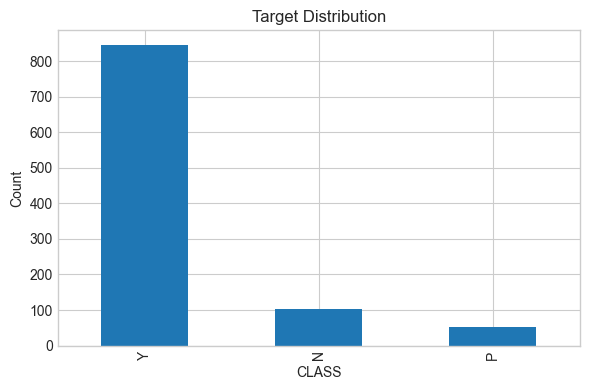

In [27]:
if y is None:
    print(f"Target column '{TARGET_COL}' not found.")
else:
    value_counts = y.value_counts(dropna=False)
    display(value_counts.to_frame("count"))

    plt.figure(figsize=(6, 4))
    value_counts.plot(kind="bar")
    plt.title("Target Distribution")
    plt.xlabel(TARGET_COL)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## 7. Numeric Feature Summary & Outliers

In [28]:
numeric_cols = X_df.select_dtypes(include="number").columns

if len(numeric_cols) == 0:
    print("No numeric columns detected.")
else:
    display(X_df[numeric_cols].describe().T)

    # Simple IQR-based outlier count
    def iqr_outlier_count(series: pd.Series) -> int:
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return int(((series < lower) | (series > upper)).sum())

    outlier_counts = {
        col: iqr_outlier_count(X_df[col].dropna())
        for col in numeric_cols
    }
    display(pd.Series(outlier_counts, name="iqr_outliers"))

    # Sanity checks for non-negative features
    non_negative_candidates = ["AGE", "BMI", "HbA1c", "Chol", "TG", "LDL", "HDL", "Cr", "Urea"]
    invalid = {
        col: int((X_df[col] < 0).sum())
        for col in non_negative_candidates
        if col in X_df.columns
    }
    if invalid:
        print("Negative value checks:")
        display(pd.Series(invalid, name="negative_count"))

,count,mean,std,min,25%,50%,75%,max
AGE,1000.0,53.528000,8.799241,20.0,51.0,55.0,59.0,79.00
Urea,1000.0,5.124743,2.935165,0.5,3.7,4.6,5.7,38.90
Cr,1000.0,68.943000,59.984747,6.0,48.0,60.0,73.0,800.00
HbA1c,1000.0,8.281160,2.534003,0.9,6.5,8.0,10.2,16.00
Chol,1000.0,4.862820,1.301738,0.0,4.0,4.8,5.6,10.30
TG,1000.0,2.349610,1.401176,0.3,1.5,2.0,2.9,13.80
HDL,1000.0,1.204750,0.660414,0.2,0.9,1.1,1.3,9.90
LDL,1000.0,2.609790,1.115102,0.3,1.8,2.5,3.3,9.90
VLDL,1000.0,1.854700,3.663599,0.1,0.7,0.9,1.5,35.00
BMI,1000.0,29.578020,4.962388,19.0,26.0,30.0,33.0,47.75


AGE      98
Urea     65
Cr       52
HbA1c     6
Chol     27
TG       55
HDL      50
LDL      11
VLDL     74
BMI       3
Name: iqr_outliers, dtype: int64

Negative value checks:


AGE      0
BMI      0
HbA1c    0
Chol     0
TG       0
LDL      0
HDL      0
Cr       0
Urea     0
Name: negative_count, dtype: int64

## 8. Univariate Distributions

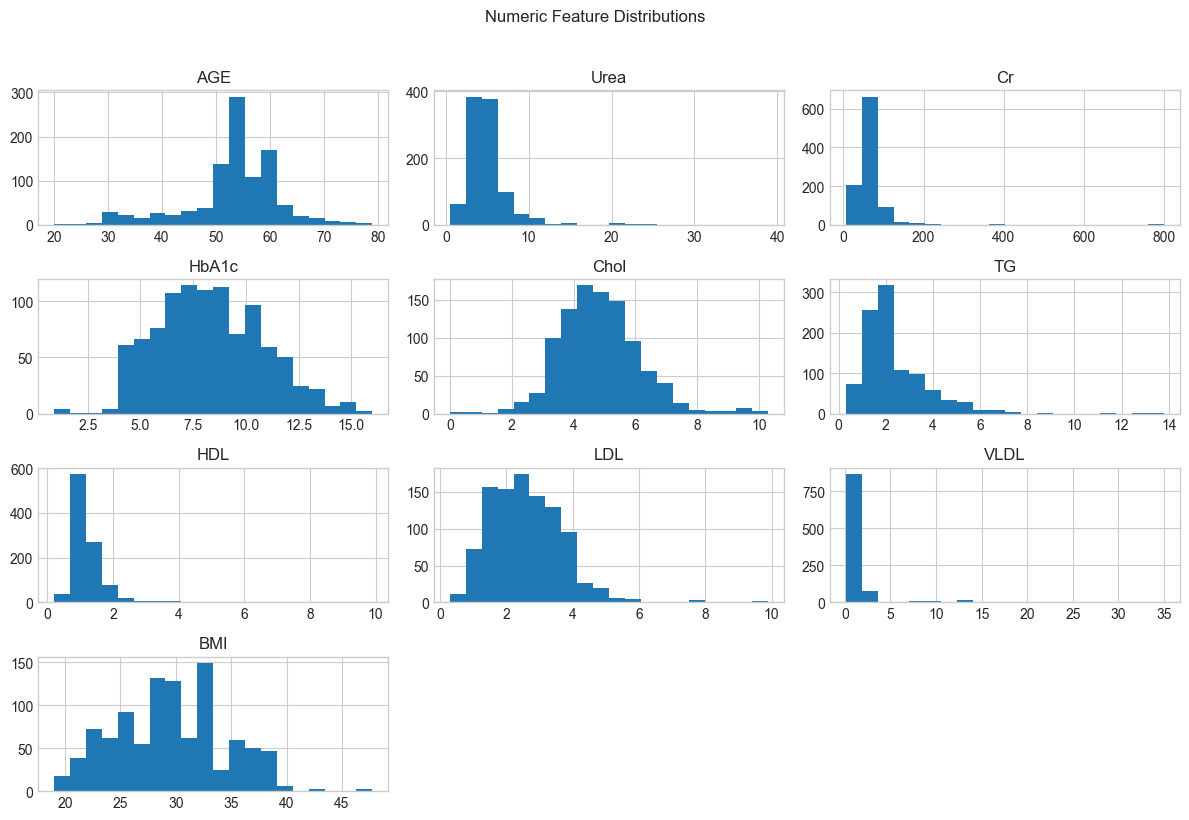

In [29]:
if len(numeric_cols) > 0:
    X_df[numeric_cols].hist(bins=20, figsize=(12, 8))
    plt.suptitle("Numeric Feature Distributions", y=1.02)
    plt.tight_layout()
    plt.show()

## 9. Target vs Feature (Boxplots)

<Figure size 600x400 with 0 Axes>

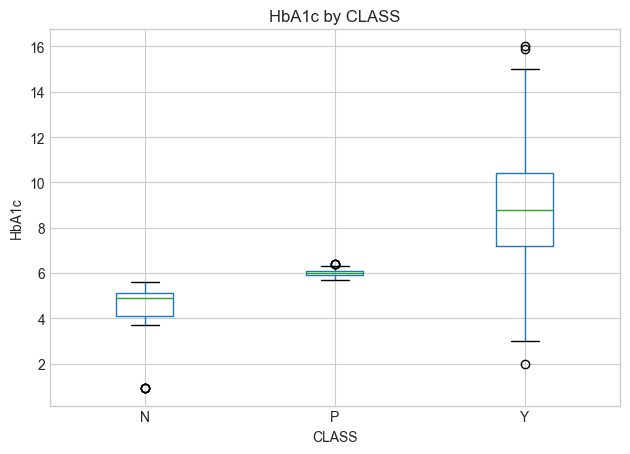

<Figure size 600x400 with 0 Axes>

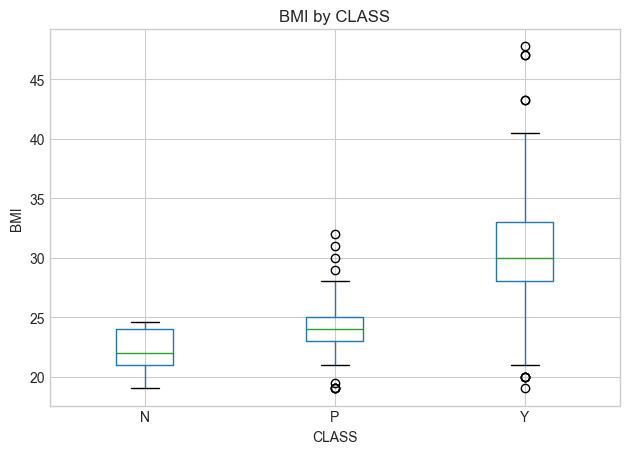

<Figure size 600x400 with 0 Axes>

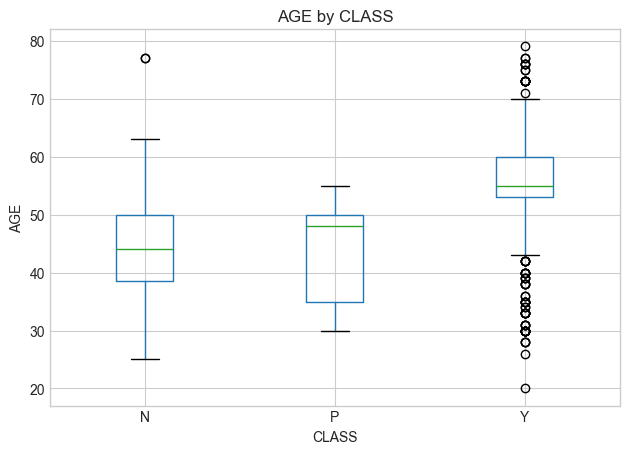

<Figure size 600x400 with 0 Axes>

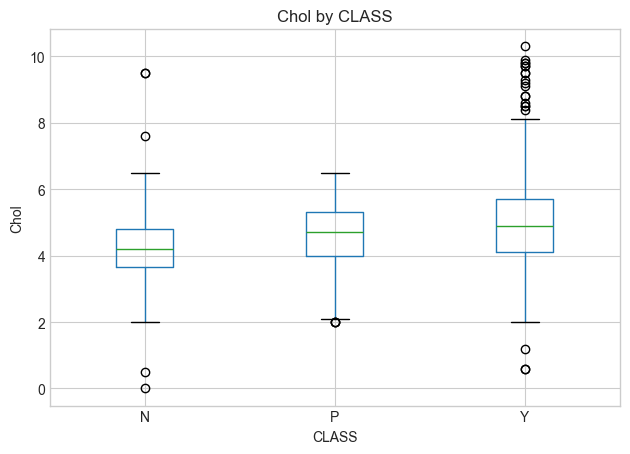

<Figure size 600x400 with 0 Axes>

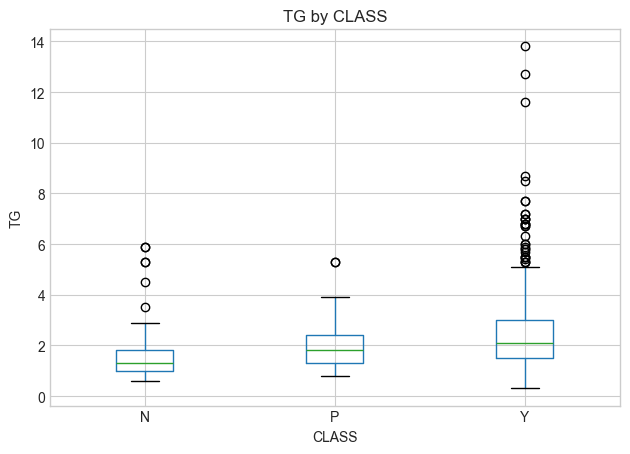

<Figure size 600x400 with 0 Axes>

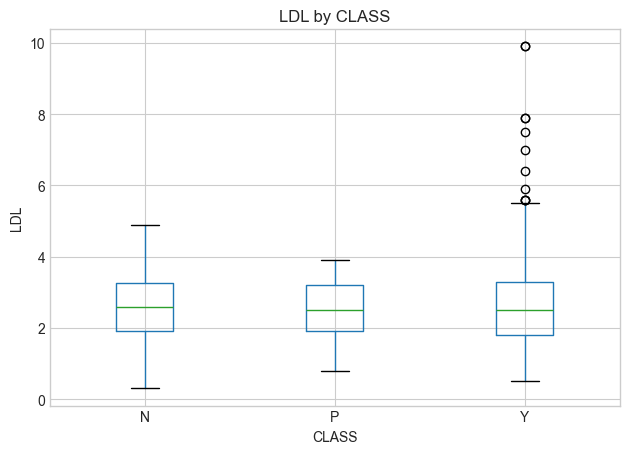

<Figure size 600x400 with 0 Axes>

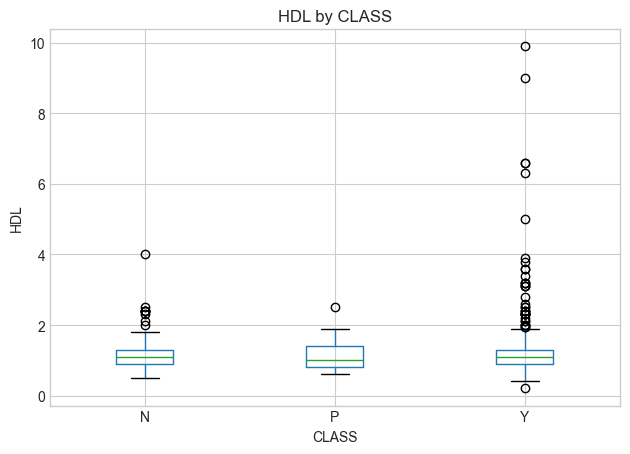

<Figure size 600x400 with 0 Axes>

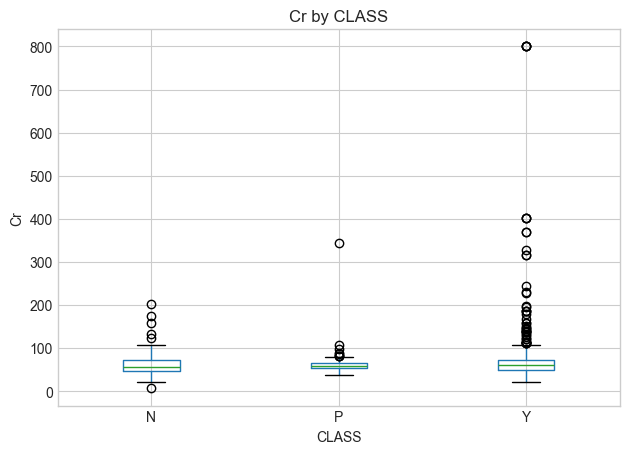

<Figure size 600x400 with 0 Axes>

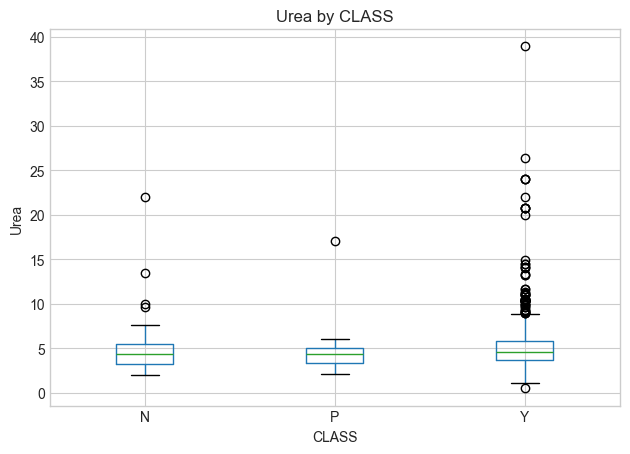

In [30]:
if y is None or len(numeric_cols) == 0:
    print("Skipping boxplots (missing target or numeric columns).")
else:
    cols = [c for c in ["HbA1c", "BMI", "AGE", "Chol", "TG", "LDL", "HDL", "Cr", "Urea"] if c in X_df.columns]
    for c in cols:
        plt.figure(figsize=(6, 4))
        df.boxplot(column=c, by=TARGET_COL)
        plt.title(f"{c} by {TARGET_COL}")
        plt.suptitle("")
        plt.xlabel(TARGET_COL)
        plt.ylabel(c)
        plt.tight_layout()
        plt.show()

## 10. Correlation Heatmap

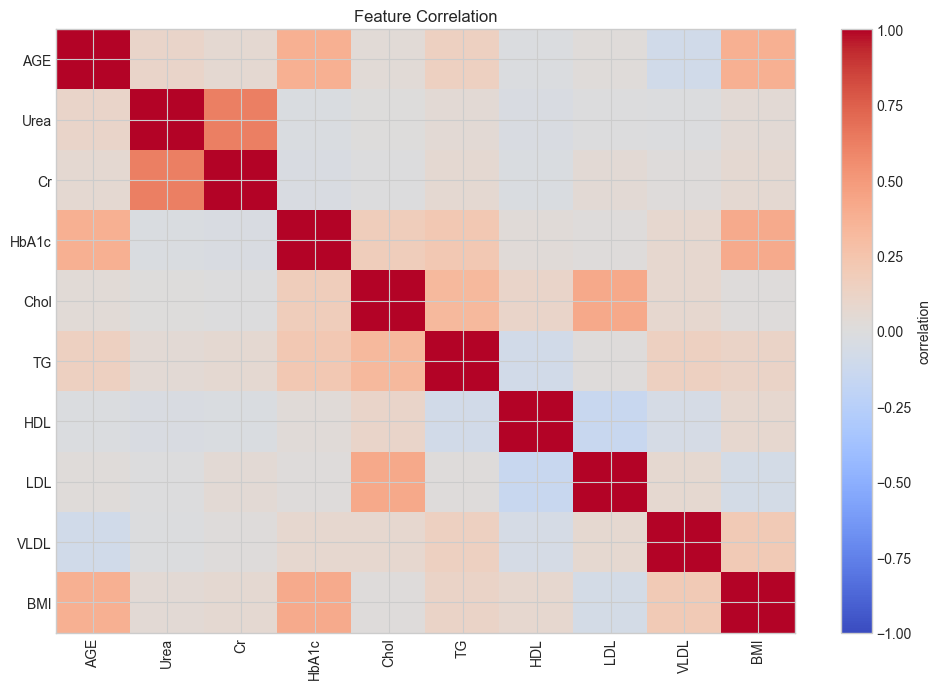

In [31]:
if len(numeric_cols) > 1:
    corr = X_df[numeric_cols].corr()

    plt.figure(figsize=(10, 7))
    plt.imshow(corr, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(label="correlation")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Feature Correlation")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation.")